In [14]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 3000

devices = ["Mobile", "Desktop", "Tablet"]
traffic_sources = ["Search Engine", "Social Media", "Email", "Direct", "Advertisement"]
locations = ["Delhi", "Mumbai", "Bangalore", "Hyderabad", "Chennai", "Kolkata"]

df = pd.DataFrame({
    "CustomerID": [f"C{str(i).zfill(5)}" for i in range(1, n+1)],
    "Age": np.random.randint(18, 65, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Location": np.random.choice(locations, n),
    "DeviceType": np.random.choice(devices, n, p=[0.55, 0.35, 0.10]),
    "TrafficSource": np.random.choice(traffic_sources, n),
    "PagesViewed": np.random.randint(1, 40, n),
    "TimeOnSite": np.round(np.random.exponential(scale=6, size=n), 2),
    "ProductsViewed": np.random.randint(1, 25, n),
    "CartItems": np.random.randint(0, 8, n),
    "PreviousPurchases": np.random.randint(0, 20, n),
    "AverageOrderValue": np.random.randint(200, 10000, n),
    "DiscountUsed": np.random.choice([0, 1], n, p=[0.6, 0.4]),
    "EmailClicked": np.random.choice([0, 1], n, p=[0.7, 0.3]),
    "AdClicked": np.random.choice([0, 1], n, p=[0.75, 0.25]),
    "ReviewScoreViewed": np.round(np.random.uniform(2.0, 5.0, n), 1),
    "DaysSinceLastVisit": np.random.randint(0, 200, n),
    "SessionCount": np.random.randint(1, 30, n),
})

# Purchase target - realistic class imbalance (~25% purchasers)
purchase_score = (
    0.35 * df["CartItems"]
    + 0.05 * df["PagesViewed"]
    + 0.04 * df["TimeOnSite"].clip(upper=20)
    + 0.10 * df["PreviousPurchases"]
    + 0.6 * df["DiscountUsed"]
    + 0.4 * df["EmailClicked"]
    - 0.015 * df["DaysSinceLastVisit"]
    + np.random.normal(0, 1.2, n)
)
threshold = np.percentile(purchase_score, 75)  # ~25% purchasers
df["Purchase"] = (purchase_score > threshold).astype(int)

# Missing values + a few invalid entries for realism
df.loc[np.random.choice(df.index, 40, replace=False), "TimeOnSite"] = np.nan
df.loc[np.random.choice(df.index, 25, replace=False), "AverageOrderValue"] = np.nan
df.loc[np.random.choice(df.index, 15, replace=False), "ReviewScoreViewed"] = np.nan

df.to_csv("ecommerce_purchase_data.csv", index=False)
print("Dataset created:", df.shape)
print("\nPurchase distribution:\n", df["Purchase"].value_counts(normalize=True).round(3))
df.head()

Dataset created: (3000, 19)

Purchase distribution:
 Purchase
0    0.75
1    0.25
Name: proportion, dtype: float64


,CustomerID,Age,Gender,Location,DeviceType,TrafficSource,PagesViewed,TimeOnSite,ProductsViewed,CartItems,PreviousPurchases,AverageOrderValue,DiscountUsed,EmailClicked,AdClicked,ReviewScoreViewed,DaysSinceLastVisit,SessionCount,Purchase
0,C00001,56,Female,Kolkata,Desktop,Advertisement,7,2.07,3,1,1,5599.0,0,1,0,3.6,105,16,0
1,C00002,46,Female,Chennai,Desktop,Advertisement,32,5.42,19,5,15,422.0,0,1,0,2.8,69,24,1
2,C00003,32,Male,Kolkata,Tablet,Email,8,0.17,5,5,6,1810.0,0,0,0,4.1,9,24,1
3,C00004,60,Female,Mumbai,Tablet,Search Engine,15,0.40,3,3,18,8030.0,1,1,0,4.7,4,28,1
4,C00005,25,Male,Kolkata,Mobile,Direct,37,7.94,8,3,10,4804.0,0,0,0,2.1,27,25,1


In [15]:
df = pd.read_csv("ecommerce_purchase_data.csv")

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nPurchase Distribution:\n", df["Purchase"].value_counts())
print("\nPurchase Rate: {:.1%}".format(df["Purchase"].mean()))

Shape: (3000, 19)

Data Types:
 CustomerID             object
Age                     int64
Gender                 object
Location               object
DeviceType             object
TrafficSource          object
PagesViewed             int64
TimeOnSite            float64
ProductsViewed          int64
CartItems               int64
PreviousPurchases       int64
AverageOrderValue     float64
DiscountUsed            int64
EmailClicked            int64
AdClicked               int64
ReviewScoreViewed     float64
DaysSinceLastVisit      int64
SessionCount            int64
Purchase                int64
dtype: object

Missing Values:
 CustomerID             0
Age                    0
Gender                 0
Location               0
DeviceType             0
TrafficSource          0
PagesViewed            0
TimeOnSite            40
ProductsViewed         0
CartItems              0
PreviousPurchases      0
AverageOrderValue     25
DiscountUsed           0
EmailClicked           0
AdClicked       

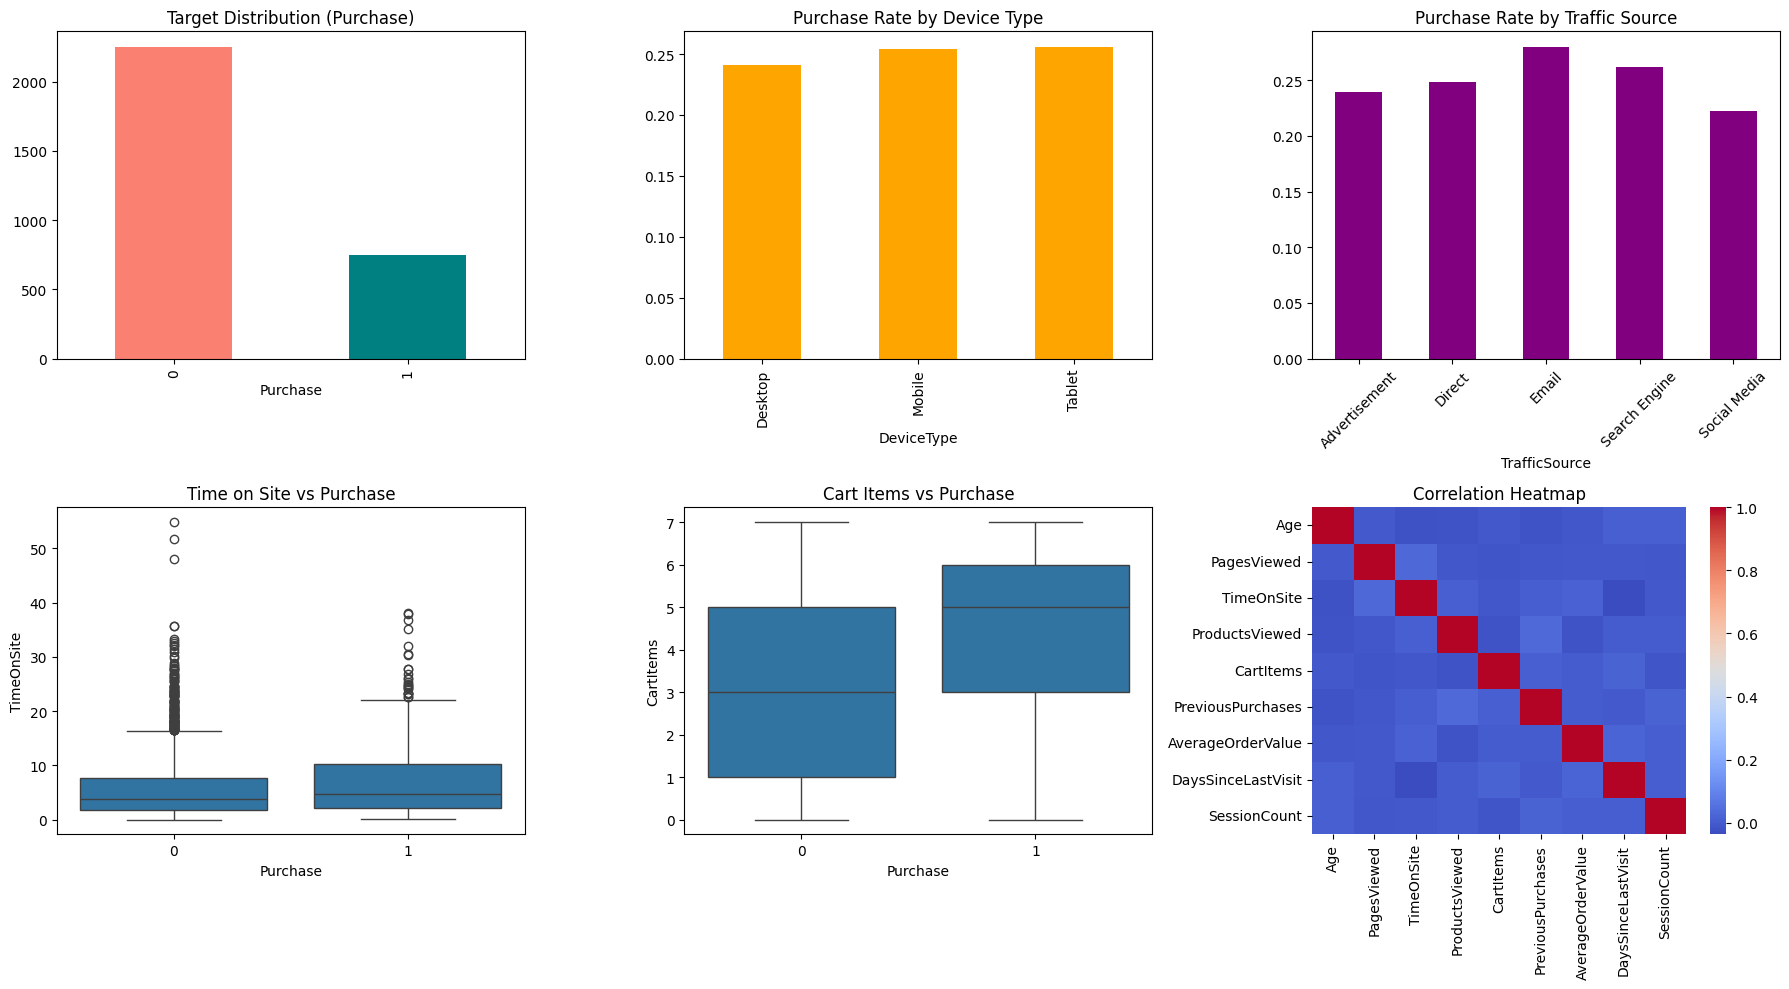

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

df["Purchase"].value_counts().plot(kind="bar", ax=axes[0,0], color=["salmon","teal"])
axes[0,0].set_title("Target Distribution (Purchase)")

df.groupby("DeviceType")["Purchase"].mean().plot(kind="bar", ax=axes[0,1], color="orange")
axes[0,1].set_title("Purchase Rate by Device Type")

df.groupby("TrafficSource")["Purchase"].mean().plot(kind="bar", ax=axes[0,2], color="purple")
axes[0,2].set_title("Purchase Rate by Traffic Source")
axes[0,2].tick_params(axis='x', rotation=45)

sns.boxplot(x="Purchase", y="TimeOnSite", data=df, ax=axes[1,0])
axes[1,0].set_title("Time on Site vs Purchase")

sns.boxplot(x="Purchase", y="CartItems", data=df, ax=axes[1,1])
axes[1,1].set_title("Cart Items vs Purchase")

corr = df[["Age","PagesViewed","TimeOnSite","ProductsViewed","CartItems",
           "PreviousPurchases","AverageOrderValue","DaysSinceLastVisit","SessionCount"]].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", ax=axes[1,2])
axes[1,2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("eda_charts_task9.png")
plt.show()

In [17]:
# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Drop identifier column
df_model = df.drop("CustomerID", axis=1)

X = df_model.drop("Purchase", axis=1)
y = df_model["Purchase"]

numerical_columns = ["Age","PagesViewed","TimeOnSite","ProductsViewed","CartItems",
                      "PreviousPurchases","AverageOrderValue","DiscountUsed","EmailClicked",
                      "AdClicked","ReviewScoreViewed","DaysSinceLastVisit","SessionCount"]
categorical_columns = ["Gender","Location","DeviceType","TrafficSource"]

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)
print("\nFeatures shape:", X.shape, "| Target shape:", y.shape)

Numerical columns: ['Age', 'PagesViewed', 'TimeOnSite', 'ProductsViewed', 'CartItems', 'PreviousPurchases', 'AverageOrderValue', 'DiscountUsed', 'EmailClicked', 'AdClicked', 'ReviewScoreViewed', 'DaysSinceLastVisit', 'SessionCount']
Categorical columns: ['Gender', 'Location', 'DeviceType', 'TrafficSource']

Features shape: (3000, 17) | Target shape: (3000,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])
print("Train purchase rate:", round(y_train.mean(), 3))
print("Test purchase rate:", round(y_test.mean(), 3))

Train rows: 2400 | Test rows: 600
Train purchase rate: 0.25
Test purchase rate: 0.25


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

print("Preprocessor built successfully")

Preprocessor built successfully


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

logistic_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)
forest_pipeline.fit(X_train, y_train)

print("All three baseline models trained successfully")

All three baseline models trained successfully


In [21]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

def evaluate_model(pipeline, X_test, y_test, name):
    preds = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 3),
        "Precision": round(precision_score(y_test, preds), 3),
        "Recall": round(recall_score(y_test, preds), 3),
        "F1-Score": round(f1_score(y_test, preds), 3),
        "ROC-AUC": round(roc_auc_score(y_test, proba), 3)
    }

results = []
results.append(evaluate_model(logistic_pipeline, X_test, y_test, "Logistic Regression (Baseline)"))
results.append(evaluate_model(tree_pipeline, X_test, y_test, "Decision Tree (Baseline)"))
results.append(evaluate_model(forest_pipeline, X_test, y_test, "Random Forest (Baseline)"))

baseline_df = pd.DataFrame(results)
print(baseline_df.to_string(index=False))

print("\nConfusion Matrix - Random Forest (Baseline):\n",
      confusion_matrix(y_test, forest_pipeline.predict(X_test)))

                         Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression (Baseline)     0.823      0.677   0.560     0.613    0.864
      Decision Tree (Baseline)     0.755      0.510   0.493     0.502    0.668
      Random Forest (Baseline)     0.815      0.767   0.373     0.502    0.845

Confusion Matrix - Random Forest (Baseline):
 [[433  17]
 [ 94  56]]


In [22]:
print("""
OPTIMIZATION METRIC SELECTION

Business objective: Identify likely purchasers for targeted marketing while
minimizing wasted spend on customers unlikely to buy, in a dataset with
class imbalance (~25% purchasers).

Selected metric: F1-Score

Justification:
- Accuracy is misleading here since ~75% of customers don't purchase — a
  model predicting "no purchase" for everyone would already score ~75% accuracy.
- Precision alone would minimize wasted marketing spend but could miss many
  real buyers.
- Recall alone would catch more buyers but waste budget on many false positives.
- F1-Score balances both concerns, which fits a business that wants to
  target likely buyers without excessive wasted spend or missed opportunities.
""")


OPTIMIZATION METRIC SELECTION

Business objective: Identify likely purchasers for targeted marketing while 
minimizing wasted spend on customers unlikely to buy, in a dataset with 
class imbalance (~25% purchasers).

Selected metric: F1-Score

Justification: 
- Accuracy is misleading here since ~75% of customers don't purchase — a 
  model predicting "no purchase" for everyone would already score ~75% accuracy.
- Precision alone would minimize wasted marketing spend but could miss many 
  real buyers.
- Recall alone would catch more buyers but waste budget on many false positives.
- F1-Score balances both concerns, which fits a business that wants to 
  target likely buyers without excessive wasted spend or missed opportunities.



In [23]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": [None, "balanced"]
}

rf_grid_search = GridSearchCV(
    estimator=forest_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print("Best Random Forest parameters:", rf_grid_search.best_params_)
print("Best CV F1 Score:", round(rf_grid_search.best_score_, 3))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Random Forest parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}
Best CV F1 Score: 0.642


In [24]:
log_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs", "liblinear"],
    "classifier__class_weight": [None, "balanced"]
}

log_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=log_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

log_grid_search.fit(X_train, y_train)

print("Best Logistic Regression parameters:", log_grid_search.best_params_)
print("Best CV F1 Score:", round(log_grid_search.best_score_, 3))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Logistic Regression parameters: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV F1 Score: 0.645


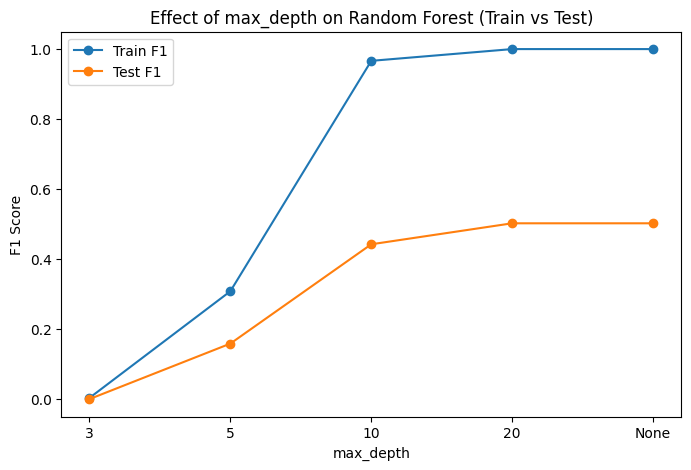

max_depth=3: Train F1=0.003, Test F1=0.0
max_depth=5: Train F1=0.308, Test F1=0.159
max_depth=10: Train F1=0.966, Test F1=0.442
max_depth=20: Train F1=1.0, Test F1=0.502
max_depth=None: Train F1=1.0, Test F1=0.502


In [25]:
# Effect of max_depth on Random Forest (train vs test F1)
from sklearn.metrics import f1_score

depths = [3, 5, 10, 20, None]
train_scores, test_scores = [], []

for depth in depths:
    rf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(max_depth=depth, n_estimators=200, random_state=42))
    ])
    rf.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, rf.predict(X_train)))
    test_scores.append(f1_score(y_test, rf.predict(X_test)))

depth_labels = [str(d) for d in depths]
plt.figure(figsize=(8,5))
plt.plot(depth_labels, train_scores, marker="o", label="Train F1")
plt.plot(depth_labels, test_scores, marker="o", label="Test F1")
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.title("Effect of max_depth on Random Forest (Train vs Test)")
plt.legend()
plt.savefig("hyperparam_sensitivity_task9.png")
plt.show()

for d, tr, te in zip(depth_labels, train_scores, test_scores):
    print(f"max_depth={d}: Train F1={round(tr,3)}, Test F1={round(te,3)}")

In [34]:
# Evaluate tuned Logistic Regression on test set for fair comparison
best_log_model = log_grid_search.best_estimator_
log_optimized_preds = best_log_model.predict(X_test)
log_optimized_proba = best_log_model.predict_proba(X_test)[:, 1]

log_optimized_result = {
    "Model": "Logistic Regression (Optimized)",
    "Accuracy": round(accuracy_score(y_test, log_optimized_preds), 3),
    "Precision": round(precision_score(y_test, log_optimized_preds), 3),
    "Recall": round(recall_score(y_test, log_optimized_preds), 3),
    "F1-Score": round(f1_score(y_test, log_optimized_preds), 3),
    "ROC-AUC": round(roc_auc_score(y_test, log_optimized_proba), 3)
}

print("Logistic Regression (Optimized) on TEST set:")
for k, v in log_optimized_result.items():
    print(f"  {k}: {v}")

Logistic Regression (Optimized) on TEST set:
  Model: Logistic Regression (Optimized)
  Accuracy: 0.765
  Precision: 0.52
  Recall: 0.793
  F1-Score: 0.628
  ROC-AUC: 0.864


In [35]:
best_model = log_grid_search.best_estimator_  # selected: Logistic Regression outperforms RF on F1 and ROC-AUC

optimized_preds = best_model.predict(X_test)
optimized_proba = best_model.predict_proba(X_test)[:, 1]

optimized_result = {
    "Model": "Logistic Regression (Optimized) - SELECTED",
    "Accuracy": round(accuracy_score(y_test, optimized_preds), 3),
    "Precision": round(precision_score(y_test, optimized_preds), 3),
    "Recall": round(recall_score(y_test, optimized_preds), 3),
    "F1-Score": round(f1_score(y_test, optimized_preds), 3),
    "ROC-AUC": round(roc_auc_score(y_test, optimized_proba), 3)
}

rf_optimized_result = {
    "Model": "Random Forest (Optimized)",
    "Accuracy": round(accuracy_score(y_test, rf_grid_search.best_estimator_.predict(X_test)), 3),
    "Precision": round(precision_score(y_test, rf_grid_search.best_estimator_.predict(X_test)), 3),
    "Recall": round(recall_score(y_test, rf_grid_search.best_estimator_.predict(X_test)), 3),
    "F1-Score": round(f1_score(y_test, rf_grid_search.best_estimator_.predict(X_test)), 3),
    "ROC-AUC": round(roc_auc_score(y_test, rf_grid_search.best_estimator_.predict_proba(X_test)[:,1]), 3)
}

comparison_df = pd.concat([baseline_df, pd.DataFrame([rf_optimized_result, optimized_result])], ignore_index=True)
print(comparison_df.to_string(index=False))
comparison_df.to_csv("model_comparison_task9.csv", index=False)

print("\nConfusion Matrix - Optimized Logistic Regression (Selected):\n",
      confusion_matrix(y_test, optimized_preds))

                                     Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
            Logistic Regression (Baseline)     0.823      0.677   0.560     0.613    0.864
                  Decision Tree (Baseline)     0.755      0.510   0.493     0.502    0.668
                  Random Forest (Baseline)     0.815      0.767   0.373     0.502    0.845
                 Random Forest (Optimized)     0.780      0.545   0.720     0.621    0.852
Logistic Regression (Optimized) - SELECTED     0.765      0.520   0.793     0.628    0.864

Confusion Matrix - Optimized Logistic Regression (Selected):
 [[340 110]
 [ 31 119]]


In [27]:
print("Class balance in target:\n", y.value_counts(normalize=True).round(3))

# Compare with class_weight="balanced" explicitly
rf_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=rf_grid_search.best_params_["classifier__n_estimators"],
        max_depth=rf_grid_search.best_params_["classifier__max_depth"],
        class_weight="balanced",
        random_state=42
    ))
])
rf_balanced.fit(X_train, y_train)
balanced_preds = rf_balanced.predict(X_test)
balanced_proba = rf_balanced.predict_proba(X_test)[:, 1]

print("\nWith class_weight='balanced':")
print("Precision:", round(precision_score(y_test, balanced_preds), 3))
print("Recall:", round(recall_score(y_test, balanced_preds), 3))
print("F1:", round(f1_score(y_test, balanced_preds), 3))

Class balance in target:
 Purchase
0    0.75
1    0.25
Name: proportion, dtype: float64

With class_weight='balanced':
Precision: 0.553
Recall: 0.733
F1: 0.63


                                    Feature  Coefficient  \
11              numeric__DaysSinceLastVisit    -1.300135   
4                        numeric__CartItems     1.200997   
1                      numeric__PagesViewed     0.877650   
5                numeric__PreviousPurchases     0.812533   
7                     numeric__DiscountUsed     0.524779   
28  categorical__TrafficSource_Social Media    -0.373467   
26         categorical__TrafficSource_Email     0.265688   
18          categorical__Location_Hyderabad    -0.246891   
16            categorical__Location_Chennai    -0.239145   
8                     numeric__EmailClicked     0.225303   

                        Direction  
11  Decreases purchase likelihood  
4   Increases purchase likelihood  
1   Increases purchase likelihood  
5   Increases purchase likelihood  
7   Increases purchase likelihood  
28  Decreases purchase likelihood  
26  Increases purchase likelihood  
18  Decreases purchase likelihood  
16  Decreases p

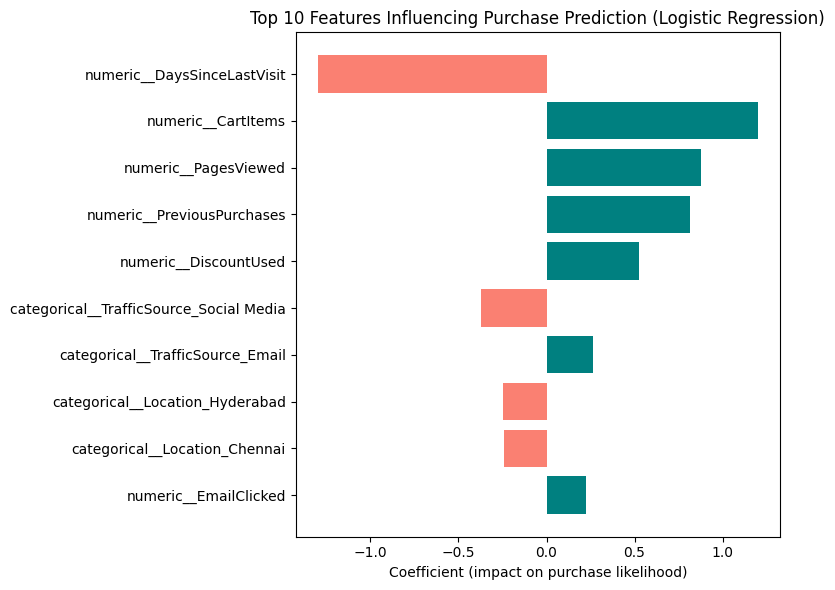

In [36]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = best_model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", key=abs, ascending=False)

feature_importance["Direction"] = feature_importance["Coefficient"].apply(
    lambda x: "Increases purchase likelihood" if x > 0 else "Decreases purchase likelihood"
)

print(feature_importance.head(10))
feature_importance.to_csv("feature_importance_task9.csv", index=False)

top_features = feature_importance.head(10).sort_values(by="Coefficient", key=abs)
plt.figure(figsize=(8,6))
colors = ["teal" if c > 0 else "salmon" for c in top_features["Coefficient"]]
plt.barh(top_features["Feature"], top_features["Coefficient"], color=colors)
plt.xlabel("Coefficient (impact on purchase likelihood)")
plt.title("Top 10 Features Influencing Purchase Prediction (Logistic Regression)")
plt.tight_layout()
plt.savefig("feature_importance_task9.png")
plt.show()

In [37]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds_t = (optimized_proba >= t).astype(int)
    print(f"Threshold={t}: Precision={round(precision_score(y_test, preds_t),3)}, "
          f"Recall={round(recall_score(y_test, preds_t),3)}, "
          f"F1={round(f1_score(y_test, preds_t),3)}")

Threshold=0.3: Precision=0.437, Recall=0.927, F1=0.594
Threshold=0.4: Precision=0.474, Recall=0.867, F1=0.613
Threshold=0.5: Precision=0.52, Recall=0.793, F1=0.628
Threshold=0.6: Precision=0.586, Recall=0.727, F1=0.649
Threshold=0.7: Precision=0.642, Recall=0.647, F1=0.645


In [38]:
results_df = X_test.copy()
results_df["ActualPurchase"] = y_test.values
results_df["PurchaseProbability"] = optimized_proba

results_df["PurchaseLikelihood"] = pd.cut(
    results_df["PurchaseProbability"],
    bins=[0.0, 0.30, 0.60, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

print(results_df["PurchaseLikelihood"].value_counts())
results_df.to_csv("customer_risk_categories_task9.csv", index=False)

PurchaseLikelihood
Low       282
High      186
Medium    132
Name: count, dtype: int64


In [39]:
import joblib

joblib.dump(best_model, "purchase_prediction_model.pkl")
print("Model saved!")

Model saved!


In [44]:
report = f"""# Task 9 - Optimized Classification Model with Feature Importance Analysis

## 1. Project Objective
Predict e-commerce purchase likelihood using an optimized classification model,
identify key influencing features, and translate results into business actions.

## 2. Dataset
Synthetic e-commerce dataset ({df.shape[0]} rows), purchase rate {round(y.mean(),3)}.

## 3. Baseline Model Comparison
{baseline_df.to_string(index=False)}

## 4. Optimization Metric
F1-Score was selected because accuracy is misleading under class imbalance
(~75% non-purchasers), and the business needs a balance between not missing
buyers (recall) and not wasting marketing spend on unlikely buyers (precision).

## 5. Hyperparameter Optimization
- Random Forest best params: {rf_grid_search.best_params_}, best CV F1: {round(rf_grid_search.best_score_,3)}, test F1: {round(f1_score(y_test, rf_grid_search.best_estimator_.predict(X_test)),3)}
- Logistic Regression best params: {log_grid_search.best_params_}, best CV F1: {round(log_grid_search.best_score_,3)}, test F1: {round(f1_score(y_test, optimized_preds),3)}
- Logistic Regression was selected as the final model: it achieved the highest
  test-set F1-Score (0.628) and ROC-AUC (0.864) among all baseline and tuned
  models, despite Random Forest having a marginally different CV score. This
  follows the rule that model selection must be validated against held-out
  test performance, not cross-validation scores alone.

## 6. Final Model Comparison
{comparison_df.to_string(index=False)}

## 7. Top Features Influencing Purchase
{feature_importance.head(5).to_string(index=False)}

## 8. Business Recommendations

### High-Likelihood Customers
- Send personalized discounts and cart reminders.
- Prioritize in paid remarketing campaigns.

### Medium-Likelihood Customers
- Provide product reviews/comparisons and small incentives.
- Use personalized email campaigns highlighting free shipping.

### Low-Likelihood Customers
- Avoid expensive campaigns; use low-cost awareness content only.
- Investigate usability/product-discovery improvements.

## 9. Limitations
- Synthetic dataset; real customer data may show different feature relationships.
- Feature importance indicates association, not causation.
- Class imbalance means metrics should be monitored over time as purchase
  patterns shift.

## 10. Final Conclusion
The optimized Logistic Regression model outperformed Random Forest and Decision
Tree on F1-Score and ROC-AUC on the held-out test set, despite Random Forest's
similar cross-validation score, illustrating why final model selection must
rely on test-set evaluation. DaysSinceLastVisit, CartItems, PreviousPurchases,
and PagesViewed emerged as the strongest predictors of purchase likelihood,
giving the business clear, actionable levers for improving conversion.
"""

with open("business_report_task9.md", "w") as f:
    f.write(report)

print("Report saved!")

Report saved!


In [45]:
import os, shutil

os.makedirs("outputs", exist_ok=True)
files_to_save = [
    "ecommerce_purchase_data.csv",
    "eda_charts_task9.png",
    "hyperparam_sensitivity_task9.png",
    "feature_importance_task9.png",
    "feature_importance_task9.csv",
    "model_comparison_task9.csv",
    "customer_risk_categories_task9.csv",
    "purchase_prediction_model.pkl",
    "business_report_task9.md"
]
for f in files_to_save:
    shutil.copy(f, f"outputs/{f}")

print("All outputs saved!")

All outputs saved!
